In [2]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")


MODEL_KEY = "xlm_roberta"
DISPLAY_NAME = "XLM-RoBERTa-base"
COLOR = "#3498DB"
CHECKPOINT = f"../checkpoints/{MODEL_KEY}/checkpoint-15522"
RESULTS_PATH = f"../checkpoints/{MODEL_KEY}/results.json"

PLOT_DIR = f"../notebooks/plots/{MODEL_KEY}/"
os.makedirs(PLOT_DIR, exist_ok=True)

CLASS_COLORS = {"hate": "#111111", "offensive": "#666666", "normal": "#CCCCCC"}
CLASS_HATCHES = {"hate": "///", "offensive": "...", "normal": ""}
CLASS_LABELS_MAP = {0: "Hate", 1: "Offensive", 2: "Normal"}

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": matplotlib.cycler(color=["#111111","#555555","#999999","#CCCCCC"]),
    "hatch.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

In [3]:
with open(f"{CHECKPOINT}/trainer_state.json", "r") as f:
    state = json.load(f)

with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

train_steps, train_loss, train_epochs = [], [], []
eval_steps, eval_epochs, eval_loss = [], [], []
eval_macro_f1, eval_weighted_f1 = [], []
eval_f1_hate, eval_f1_offensive, eval_f1_normal = [], [], []
lr_vals, grad_vals = [], []

for h in state["log_history"]:
    if "loss" in h:
        train_steps.append(h["step"])
        train_loss.append(h["loss"])
        train_epochs.append(h["epoch"])
        lr_vals.append(h.get("learning_rate", 0))
        grad_vals.append(h.get("grad_norm", 0))
    elif "eval_loss" in h:
        eval_steps.append(h["step"])
        eval_epochs.append(h["epoch"])
        eval_loss.append(h["eval_loss"])
        eval_macro_f1.append(h.get("eval_macro_f1", 0))
        eval_weighted_f1.append(h.get("eval_weighted_f1", 0))
        eval_f1_hate.append(h.get("eval_f1_hate", 0))
        eval_f1_offensive.append(h.get("eval_f1_offensive", 0))
        eval_f1_normal.append(h.get("eval_f1_normal", 0))

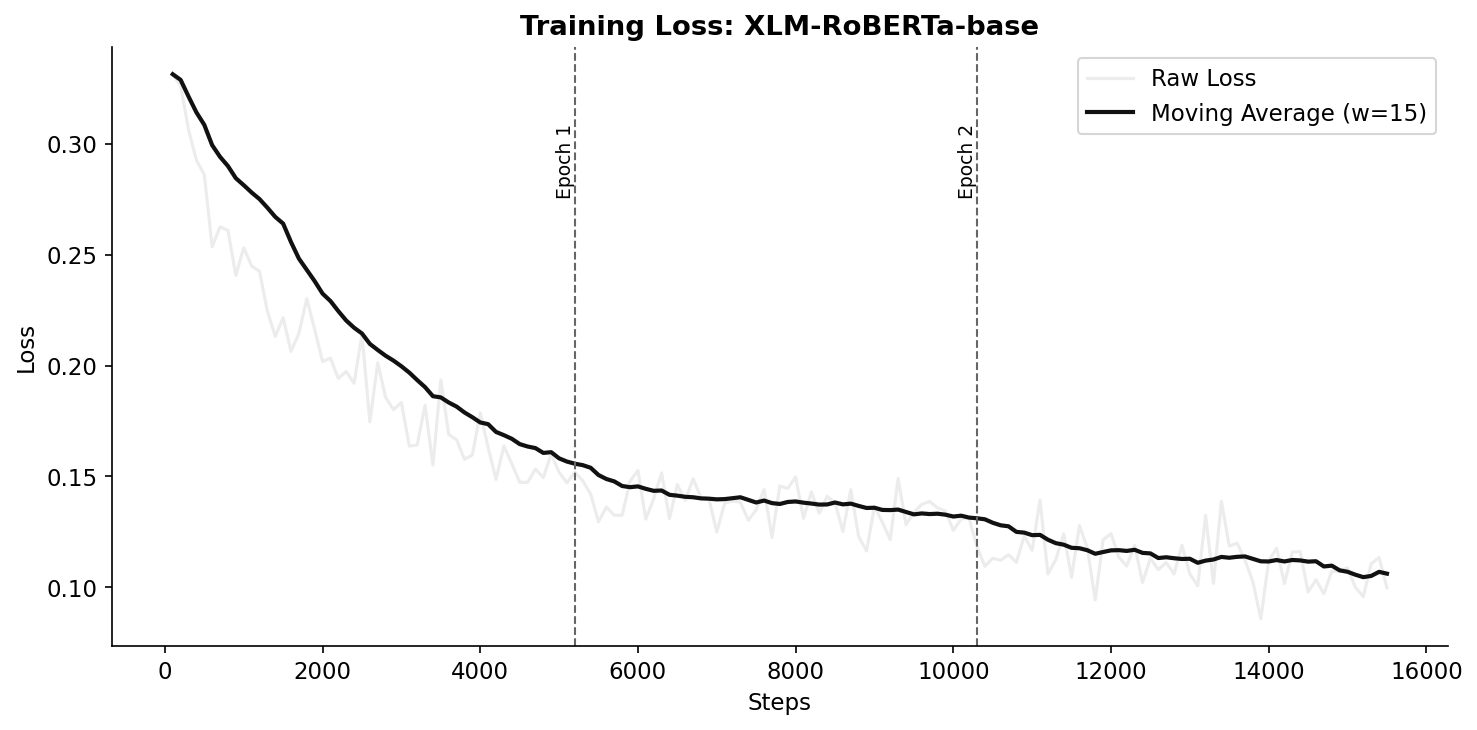

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, color="#E0E0E0", label="Raw Loss", alpha=0.6)

smooth_loss = pd.Series(train_loss).rolling(window=15, min_periods=1).mean()
plt.plot(train_steps, smooth_loss, color="#111111", linestyle="-", linewidth=2, label="Moving Average (w=15)")

epochs_done = int(max(train_epochs))
for e in range(1, epochs_done + 1):
    idx = (np.abs(np.array(train_epochs) - e)).argmin()
    step_val = train_steps[idx]
    plt.axvline(x=step_val, color="#666666", linestyle="--", linewidth=1)
    plt.text(step_val, plt.ylim()[1] * 0.9, f"Epoch {e}", rotation=90, va="top", ha="right", fontsize=9)

plt.title(f"Training Loss: {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}training_loss.png")
plt.show()

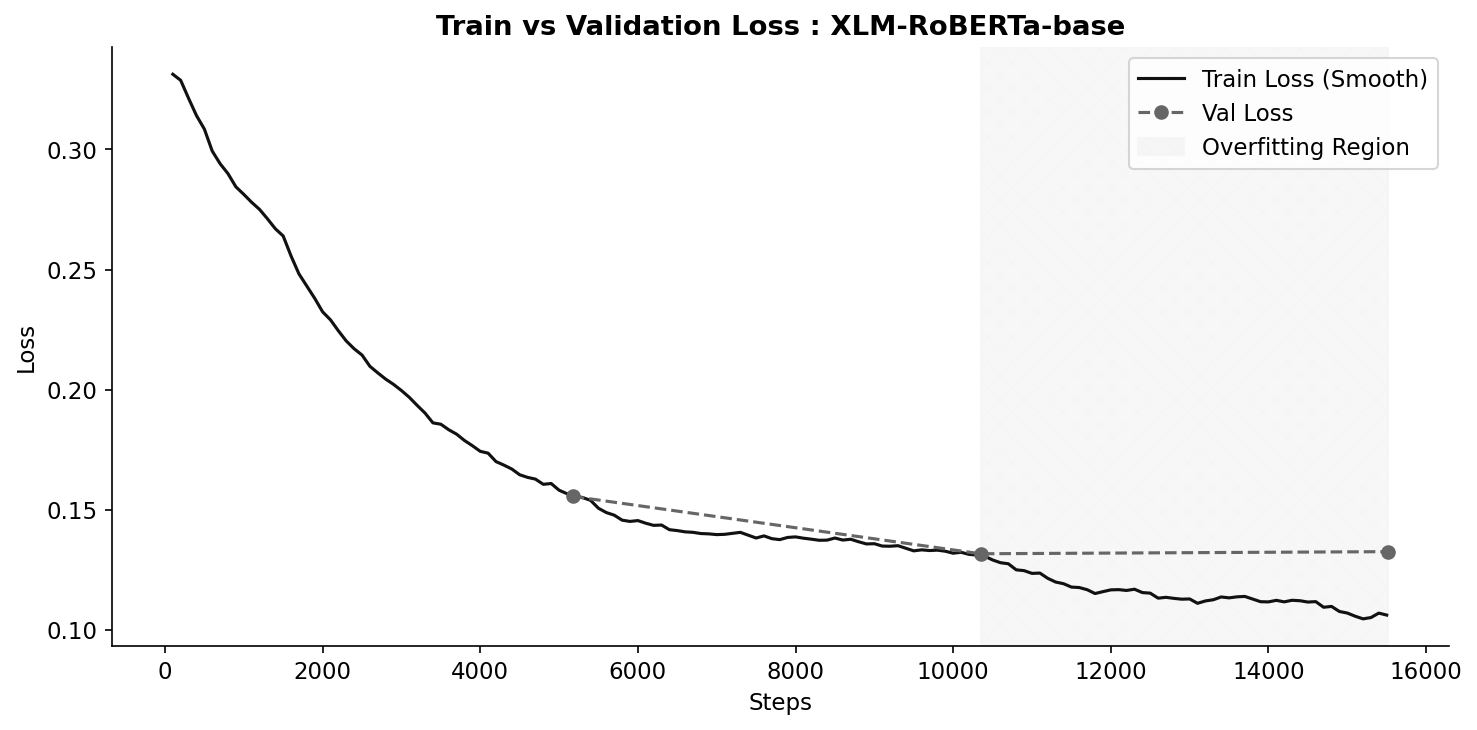

In [5]:
plt.figure(figsize=(10, 5))

train_smooth = pd.Series(train_loss).rolling(window=15, min_periods=1).mean()
plt.plot(train_steps, train_smooth, color="#111111", linestyle="-", label="Train Loss (Smooth)")
plt.plot(eval_steps, eval_loss, color="#666666", linestyle="--", marker="o", label="Val Loss")

# Highlight validation loss upward trajectories to signal overfitting
best_val_idx = np.argmin(eval_loss)
if best_val_idx < len(eval_loss) - 1:
    overfit_start = eval_steps[best_val_idx]
    overfit_end = eval_steps[-1]
    if eval_loss[-1] > eval_loss[best_val_idx]:
        plt.axvspan(overfit_start, overfit_end, color="#F5F5F5", alpha=0.8, hatch="xx", label="Overfitting Region")

plt.title(f"Train vs Validation Loss : {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}train_val_loss.png")
plt.show()

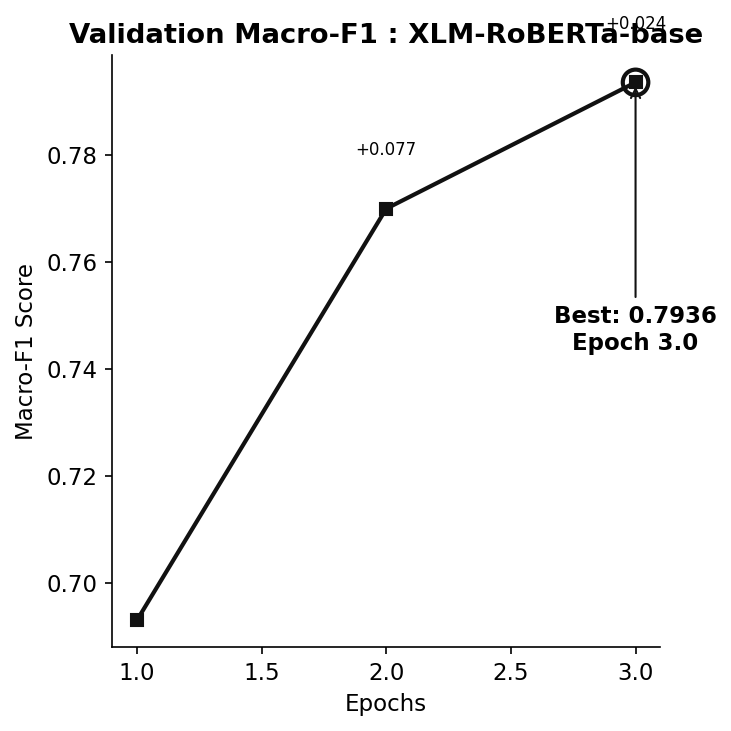

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(eval_epochs, eval_macro_f1, color="#111111", linestyle="-", marker="s", linewidth=2, label="Macro F1")

best_idx = np.argmax(eval_macro_f1)
best_epoch = eval_epochs[best_idx]
best_f1 = eval_macro_f1[best_idx]

plt.scatter(best_epoch, best_f1, color="#111111", s=150, zorder=5, facecolors="none", edgecolors="#111111", linewidths=2)
plt.annotate(f"Best: {best_f1:.4f}\nEpoch {best_epoch:.1f}", 
             xy=(best_epoch, best_f1), 
             xytext=(best_epoch, best_f1 - 0.05),
             arrowprops=dict(arrowstyle="->", color="#111111"),
             fontweight="bold", ha="center")

for i in range(1, len(eval_macro_f1)):
    diff = eval_macro_f1[i] - eval_macro_f1[i-1]
    plt.text(eval_epochs[i], eval_macro_f1[i] + 0.01, f"{diff:+.3f}", fontsize=8, ha="center")

plt.title(f"Validation Macro-F1 : {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Macro-F1 Score")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}validation_macro_f1.png")
plt.show()

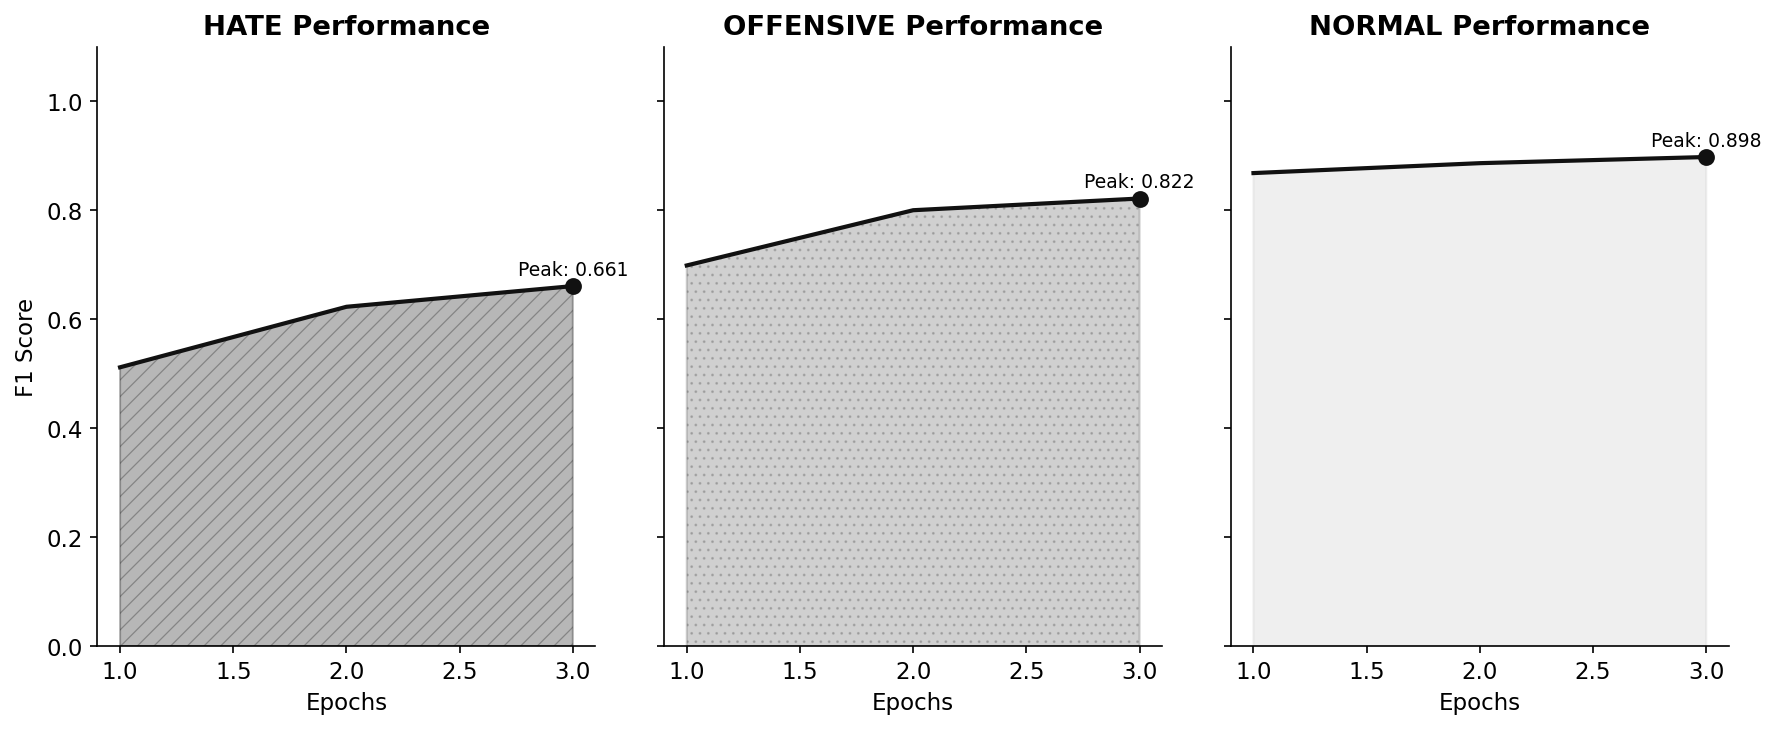

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
classes = [("hate", eval_f1_hate), ("offensive", eval_f1_offensive), ("normal", eval_f1_normal)]

for i, (name, data) in enumerate(classes):
    ax = axes[i]
    ax.plot(eval_epochs, data, color="#111111", linestyle="-", linewidth=2, label=f"{name.upper()} F1")
    ax.fill_between(eval_epochs, data, color=CLASS_COLORS[name], alpha=0.3, hatch=CLASS_HATCHES[name])
    
    peak_idx = np.argmax(data)
    ax.scatter(eval_epochs[peak_idx], data[peak_idx], color="#111111", s=50)
    ax.text(eval_epochs[peak_idx], data[peak_idx] + 0.02, f"Peak: {data[peak_idx]:.3f}", ha="center", fontsize=9)
    
    ax.set_title(f"{name.upper()} Performance", fontweight="bold")
    ax.set_xlabel("Epochs")
    if i == 0:
        ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}per_class_f1_evolution.png")
plt.show()

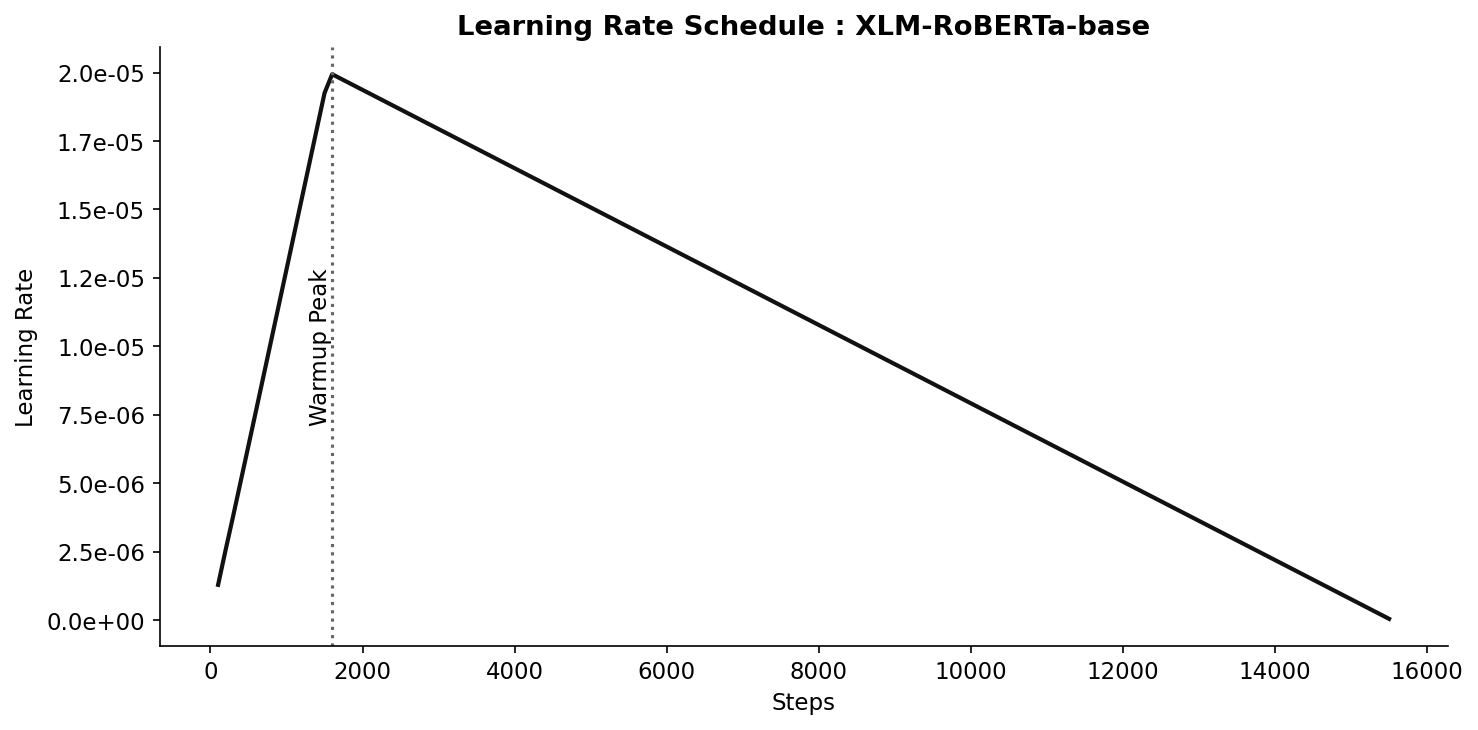

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_steps, lr_vals, color="#111111", linestyle="-", linewidth=2)

peak_idx = np.argmax(lr_vals)
plt.axvline(x=train_steps[peak_idx], color="#666666", linestyle=":")
plt.text(train_steps[peak_idx], max(lr_vals) * 0.5, "Warmup Peak", rotation=90, va="center", ha="right")

plt.title(f"Learning Rate Schedule : {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1e"))
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}learning_rate.png")
plt.show()

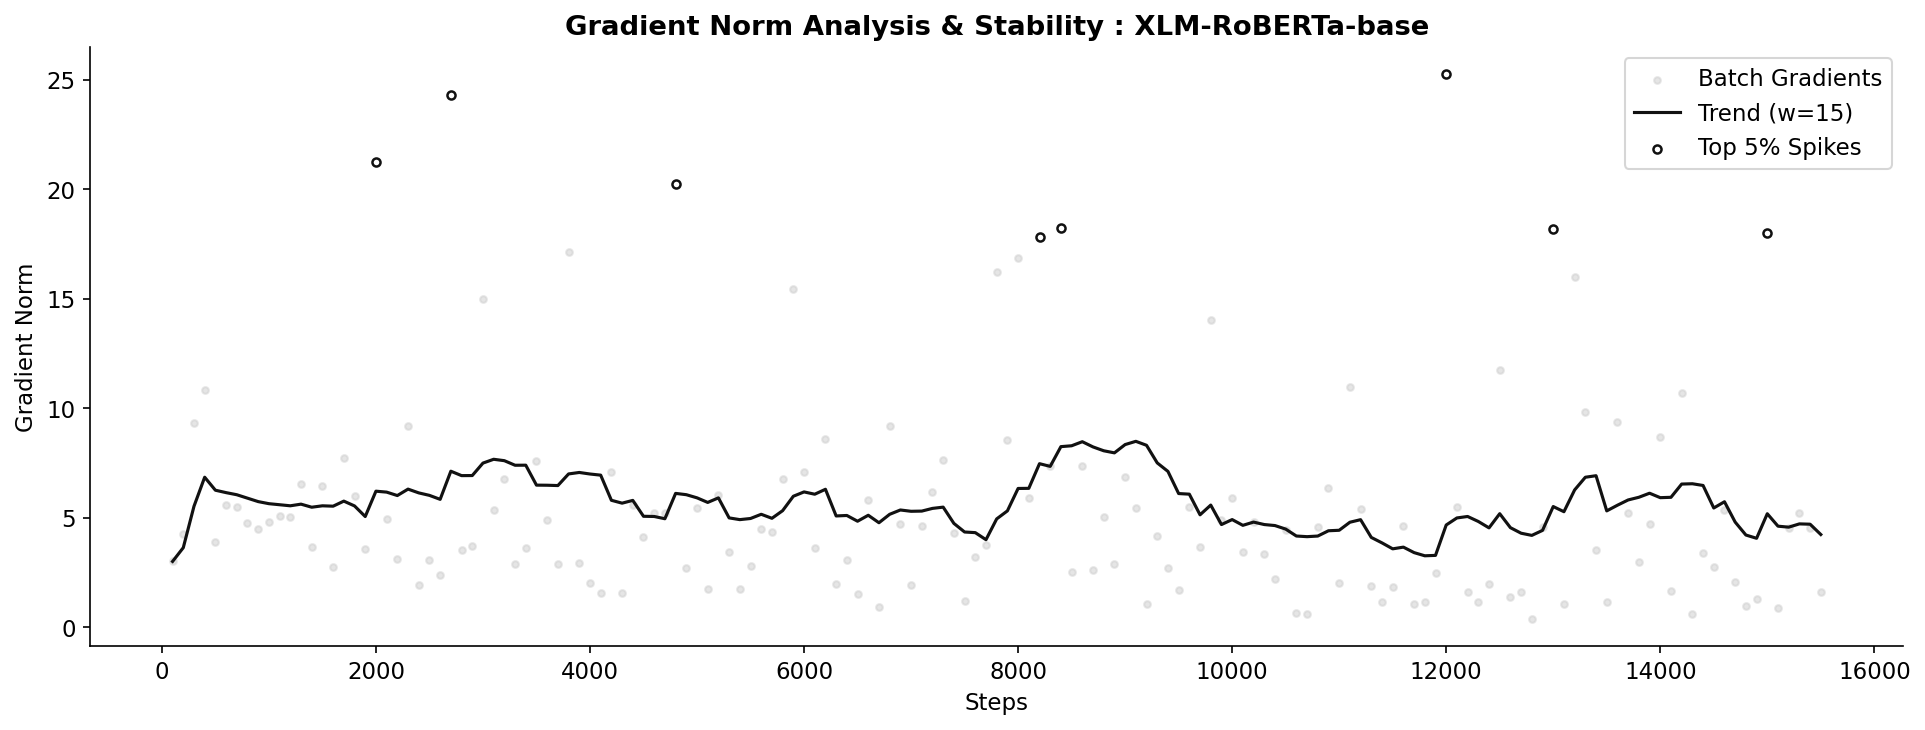

In [9]:
plt.figure(figsize=(13, 5))
plt.scatter(train_steps, grad_vals, color="#CCCCCC", alpha=0.5, s=10, label="Batch Gradients")

smooth_grads = pd.Series(grad_vals).rolling(window=15, min_periods=1).mean()
plt.plot(train_steps, smooth_grads, color="#111111", linestyle="-", linewidth=1.5, label="Trend (w=15)")

threshold = np.percentile(grad_vals, 95)
spikes_idx = [i for i, v in enumerate(grad_vals) if v > threshold]
plt.scatter(np.array(train_steps)[spikes_idx], np.array(grad_vals)[spikes_idx], 
            color="#FFFFFF", edgecolor="#111111", s=15, linewidths=1.2, label="Top 5% Spikes")

plt.title(f"Gradient Norm Analysis & Stability : {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Steps")
plt.ylabel("Gradient Norm")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}gradient_norms.png")
plt.show()

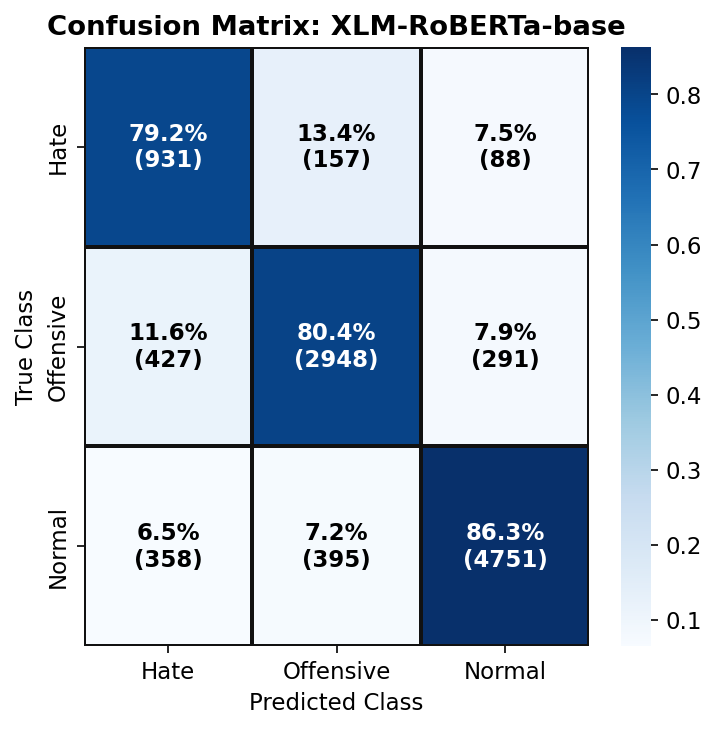

In [10]:
cm = np.array(results["confusion_matrix"])
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
labels = ["Hate", "Offensive", "Normal"]

plt.figure(figsize=(5, 5))
sns.heatmap(cm_norm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels, 
            cbar=True, linewidths=1, linecolor="#111111")

for i in range(3):
    for j in range(3):
        plt.text(j + 0.5, i + 0.5, f"{cm_norm[i, j]*100:.1f}%\n({cm[i, j]})",
                 ha="center", va="center", 
                 color="white" if cm_norm[i, j] > 0.5 else "black",
                 fontweight="bold")

plt.title(f"Confusion Matrix: {DISPLAY_NAME}", fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}confusion_matrix.png")
plt.show()

In [11]:
print("=======================================================================")
print(f"               CLASSIFICATION REPORT — {DISPLAY_NAME.upper()}")
print("=======================================================================")
print(results["report"])
print("-----------------------------------------------------------------------")
print(f"Macro-F1    : {results['macro_f1']:.4f}")
print(f"Weighted-F1 : {results['weighted_f1']:.4f}")

# Extract accuracy approximation from report if explicitly absent as a standalone key
if "accuracy" in results:
    print(f"Accuracy    : {results['accuracy']:.4f}")
else:
    rep_lines = results["report"].split("\n")
    for line in rep_lines:
        if "accuracy" in line:
            parts = line.split()
            print(f"Accuracy    : {parts[-2]}")
print("=======================================================================")

               CLASSIFICATION REPORT — XLM-ROBERTA-BASE
              precision    recall  f1-score   support

        hate     0.5425    0.7917    0.6438      1176
   offensive     0.8423    0.8041    0.8228      3666
      normal     0.9261    0.8632    0.8935      5504

    accuracy                         0.8341     10346
   macro avg     0.7703    0.8197    0.7867     10346
weighted avg     0.8528    0.8341    0.8401     10346

-----------------------------------------------------------------------
Macro-F1    : 0.7867
Weighted-F1 : 0.8401
Accuracy    : 0.8341


In [12]:
total_epochs = max(train_epochs) if train_epochs else 0
best_val_macro = max(eval_macro_f1) if eval_macro_f1 else 0
runtime = state.get("total_flops", "N/A")

if "train_runtime" in state:
    runtime = f"{state['train_runtime']:.1f} seconds"

# Parse your exact dictionary structure safely
raw_per_class = results.get("per_class_f1", {})
f1_hate = raw_per_class.get("hate", 0.0)
f1_off  = raw_per_class.get("offensive", 0.0)
f1_norm = raw_per_class.get("normal", 0.0)

print("┌─────────────────────────────────────────────────────────────────────┐")
print(f"  MODEL METRIC SUMMARY CARD: {DISPLAY_NAME:<41}")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"  Total Training Epochs  : {total_epochs:<42.1f}")
print(f"  Best Val Macro-F1      : {best_val_macro:<42.4f}")
print(f"  Test Data Macro-F1     : {results['macro_f1']:<42.4f}")
print(f"  Test Data Weighted-F1  : {results['weighted_f1']:<42.4f}")
print("├─────────────────────────────────────────────────────────────────────┤")
print("  PER-CLASS TEST METRICS (F1-Score):                                  ")
print(f"    - Hate Speech        : {f1_hate:.4f}")
print(f"    - Offensive Language : {f1_off:.4f}")
print(f"    - Normal / Neutral   : {f1_norm:.4f}")
print("├─────────────────────────────────────────────────────────────────────┤")

┌─────────────────────────────────────────────────────────────────────┐
  MODEL METRIC SUMMARY CARD: XLM-RoBERTa-base                         
├─────────────────────────────────────────────────────────────────────┤
  Total Training Epochs  : 3.0                                       
  Best Val Macro-F1      : 0.7936                                    
  Test Data Macro-F1     : 0.7867                                    
  Test Data Weighted-F1  : 0.8401                                    
├─────────────────────────────────────────────────────────────────────┤
  PER-CLASS TEST METRICS (F1-Score):                                  
    - Hate Speech        : 0.6438
    - Offensive Language : 0.8228
    - Normal / Neutral   : 0.8935
├─────────────────────────────────────────────────────────────────────┤
